# Lab 9 — Capacity-Approaching Codes: LDPC and Polar

**Companion to Chapter 9.** 5G NR uses LDPC codes for user data and polar codes
for control information; 6G studies have agreed to largely reuse them. This lab
builds both from scratch (`commlib/coding.py`) so you can see every message.

1. Construct an LDPC code with progressive edge growth and inspect its Tanner graph.
2. Decode with belief propagation (sum-product) and normalized min-sum; study iterations.
3. Watch channel polarization happen and pick a polar code's information set.
4. Compare SC with CRC-aided successive-cancellation list decoding.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown
import commlib as cl

cl.style()
rng = np.random.default_rng(9)

def bpsk_llr(cw, ebn0_db, rate, r=rng):
    sigma = np.sqrt(1 / (2 * rate * 10 ** (ebn0_db / 10)))
    y = (1 - 2 * cw.astype(float)) + sigma * r.standard_normal(len(cw))
    return 2 * y / sigma ** 2

## 1. An LDPC code and its Tanner graph
$\mathbf{H}$ is sparse: here each variable node has degree 3 and each check about 6
(a (3,6)-regular ensemble, rate 1/2). PEG construction greedily maximizes the local
girth, avoiding the 4-cycles that hurt belief propagation.

n = 576, k = 288, rate = 0.500, edges = 1728
pairs of checks sharing >1 variable (4-cycles): 36


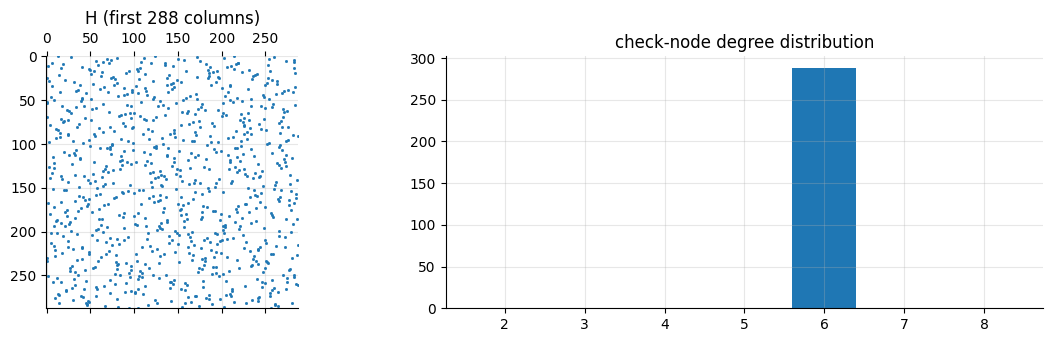

In [3]:
code = cl.LDPCCode(n=576, rate=0.5, dv=3, seed=3)
print(f"n = {code.n}, k = {code.k}, rate = {code.rate:.3f}, edges = {code.E}")
Hm = code.H.astype(int)
four_cycles = int(((Hm @ Hm.T) - np.diag(Hm.sum(1)) > 1).sum() // 2)
print(f"pairs of checks sharing >1 variable (4-cycles): {four_cycles}")
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].spy(code.H[:, :288], markersize=1); ax[0].set_title("H (first 288 columns)")
ax[1].hist(code.H.sum(axis=1), bins=np.arange(2, 10) - 0.5, rwidth=0.8); ax[1].set_title("check-node degree distribution")
plt.tight_layout(); plt.show()

## 2. Belief propagation: BER and FER
Sum-product passes exact LLR messages; min-sum replaces the check update's
$2\tanh^{-1}\prod\tanh(\cdot/2)$ by sign×min, scaled by $\alpha \approx 0.8$ to correct
its over-confidence. Hardware decoders (including 5G basebands) use layered
normalized/offset min-sum.

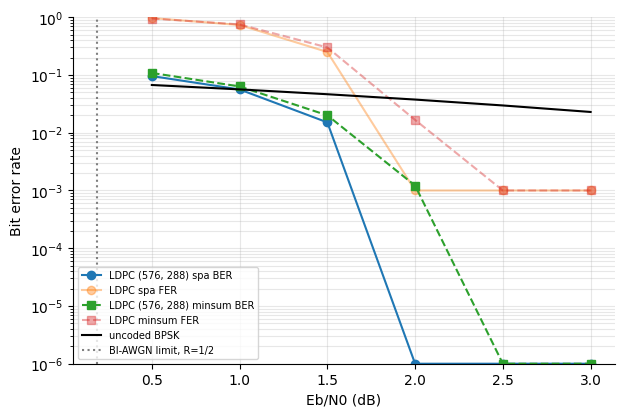

In [5]:
def ldpc_curve(ebn0s, method, frames=60, iters=50):
    ber, fer = [], []
    for e in ebn0s:
        be = fe = 0
        for f in range(frames):
            r = np.random.default_rng(1000 + f)
            u = cl.random_bits(code.k, r)
            cw = code.encode(u)
            ch = code.decode(bpsk_llr(cw, e, code.rate, r), iters=iters, method=method)
            ne = np.sum(code.info_bits(ch) != u)
            be += ne; fe += ne > 0
        ber.append(be / (frames * code.k)); fer.append(fe / frames)
    return np.array(ber), np.array(fer)

eb = np.arange(0.5, 3.1, 0.5)
cc = cl.ConvCode()
fig, ax = plt.subplots(figsize=(7, 4.5))
for m, st in [("spa", "o-"), ("minsum", "s--")]:
    b, f = ldpc_curve(eb, m)
    ax.semilogy(eb, np.maximum(b, 1e-6), st, label=f"LDPC (576, 288) {m} BER")
    ax.semilogy(eb, np.maximum(f, 1e-3), st, alpha=0.4, label=f"LDPC {m} FER")
ax.semilogy(eb, cl.ber_bpsk(eb), "k", label="uncoded BPSK")
ax.axvline(0.19, color="gray", ls=":", label="BI-AWGN limit, R=1/2")
cl.ber_axes(ax); ax.set_ylim(1e-6, 1); ax.legend(fontsize=7); plt.show()

Longer codes approach the limit more closely: NR base graph 1 supports up to 8448
information bits per code block, and at such lengths LDPC is within about 1 dB of
capacity at FER 10⁻².

### Interactive: iterations and the waterfall
How many iterations does BP actually need? The decoder stops when the syndrome is
zero, so at good SNR the average iteration count, and therefore power, drops.

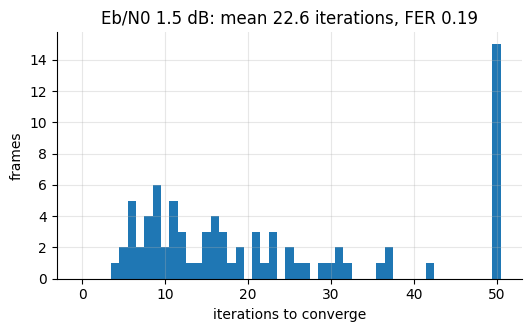

In [8]:
def iter_view(ebn0_db=1.5, method="minsum", max_iters=50):
    its, fails = [], 0
    for f in range(80):
        r = np.random.default_rng(f)
        u = cl.random_bits(code.k, r)
        ch, it = code.decode(bpsk_llr(code.encode(u), ebn0_db, code.rate, r), iters=max_iters,
                             method=method, return_iters=True)
        its.append(it); fails += np.any(code.info_bits(ch) != u)
    fig, ax = plt.subplots(figsize=(6, 3.2))
    ax.hist(its, bins=np.arange(0, max_iters + 2) - 0.5)
    ax.set_xlabel("iterations to converge"); ax.set_ylabel("frames")
    ax.set_title(f"Eb/N0 {ebn0_db} dB: mean {np.mean(its):.1f} iterations, FER {fails/80:.2f}")
    plt.show()

interact(iter_view, ebn0_db=FloatSlider(value=1.5, min=0, max=4, step=0.25),
         method=Dropdown(options=["minsum", "spa"]), max_iters=IntSlider(value=50, min=5, max=100, step=5));

## 3. Channel polarization
Arıkan's transform $\mathbf{G}_N = \mathbf{F}^{\otimes n}$ turns N copies of a channel
into synthetic bit-channels that are either nearly perfect or nearly useless.
The Bhattacharyya parameter $Z$ (an upper bound on bit-channel error probability)
evolves as $Z^- = 2Z - Z^2$, $Z^+ = Z^2$. We plot it for N=1024 on an erasure-like
design channel with $Z_0 = 0.5$.

fraction with Z<1e-3: 0.336, with Z>1-1e-3: 0.336  (capacity = 0.5)


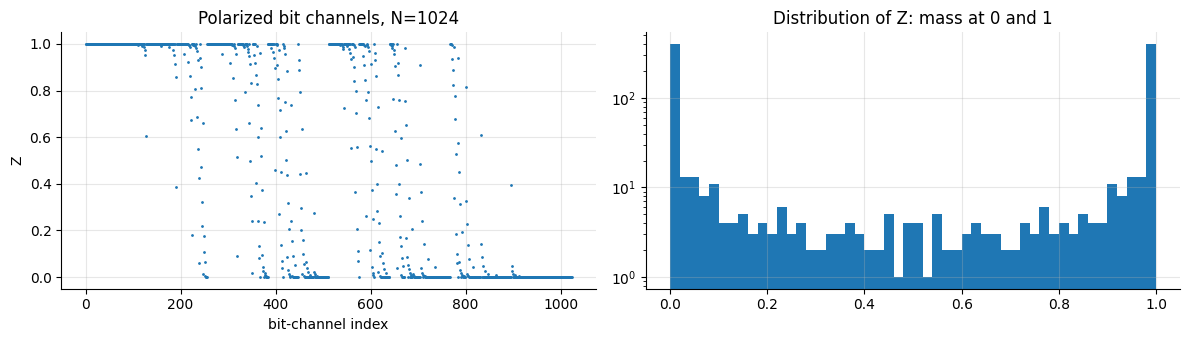

In [10]:
Z = cl.PolarCode._bhat(1024, 0.5)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].plot(Z, ".", ms=2); ax[0].set_xlabel("bit-channel index"); ax[0].set_ylabel("Z"); ax[0].set_title("Polarized bit channels, N=1024")
ax[1].hist(Z, 50); ax[1].set_yscale("log"); ax[1].set_title("Distribution of Z: mass at 0 and 1")
plt.tight_layout(); plt.show()
print(f"fraction with Z<1e-3: {np.mean(Z<1e-3):.3f}, with Z>1-1e-3: {np.mean(Z>1-1e-3):.3f}  (capacity = 0.5)")

## 4. SC versus CRC-aided SC list decoding
Plain SC decoding is capacity-achieving asymptotically but weak at practical
lengths. Keeping the $L$ best paths and letting a CRC choose among them (CA-SCL)
is what made polar codes competitive; NR control channels use lists of 8 with
CRC-11 or CRC-24. Here: N=256, K=128 with CRC-11.

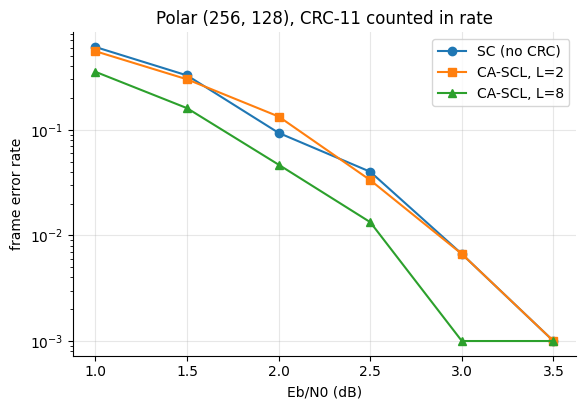

In [12]:
def polar_fer(ebn0s, L, frames=150, crc=True):
    pc = cl.PolarCode(256, 128, design_snr_db=2.0, crc_poly=cl.CRC11_5G if crc else None)
    rate = 128 / 256
    out = []
    for e in ebn0s:
        fe = 0
        for f in range(frames):
            r = np.random.default_rng(5000 + f)
            u = cl.random_bits(128, r)
            fe += not np.array_equal(pc.decode(bpsk_llr(pc.encode(u), e, rate, r), L=L), u)
        out.append(fe / frames)
    return np.array(out)

eb = np.arange(1.0, 3.6, 0.5)
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.semilogy(eb, np.maximum(polar_fer(eb, 1, crc=False), 1e-3), "o-", label="SC (no CRC)")
ax.semilogy(eb, np.maximum(polar_fer(eb, 2), 1e-3), "s-", label="CA-SCL, L=2")
ax.semilogy(eb, np.maximum(polar_fer(eb, 8), 1e-3), "^-", label="CA-SCL, L=8")
ax.set_xlabel("Eb/N0 (dB)"); ax.set_ylabel("frame error rate"); ax.legend()
ax.set_title("Polar (256, 128), CRC-11 counted in rate"); plt.show()

## Exercises
1. **(Warm-up)** Show that the check-node update of sum-product equals
   $\mathrm{sign}\cdot\min$ in the limit of large LLRs.
2. **(Core)** Implement layered (row-by-row) min-sum scheduling and show it converges
   in roughly half the iterations of flooding.
3. **(Core)** Replace the Bhattacharyya construction with the 5G NR reliability
   sequence from TS 38.212 Table 5.3.1.2-1 and compare FER at N=256.
4. **(Stretch)** Implement rate matching for the polar code (puncturing and
   shortening per 38.212) to support N=256, E=200, and measure the loss.